In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats



Q1.
1. Set up a grid of equally spaced values between 0 and 1, {1/K, 2/K, ..., K/K}.
2. Draw a point from the grid at random with equal probability.
3. For a very small K, repeat the above process n = 5_000 times, and plot the ECDF of the draws.
4. What distribution does this approach as you increase K?
    When K is equal to 5 the ECDF resembles a staircase from 0 to 1 increasing evenly 5 times. As I increase K the line begins to resemble a linear relationship from 0 to 1. It looks to approach a uniform distribution; furthermore, a uniform distribution CDF is F(x) = x (or linear) from 0 to 1.

<Axes: ylabel='Proportion'>

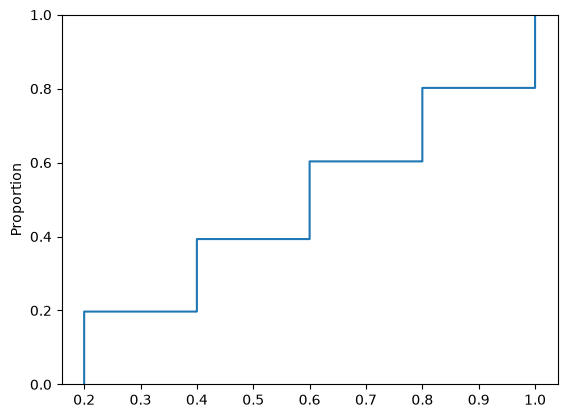

In [19]:
#1. Set up a grid of equally spaced values between 0 and 1, {1/K, 2/K, ..., K/K}.
K = 100
ES_Grid = np.linspace(1/K, 1, K)

#2. Draw a point from the grid at random with equal probability.
pick = np.random.default_rng().choice(ES_Grid)

#3. For a very small K, repeat the above process n = 5_000 times, and plot the ECDF of the draws.
n = 5000
K = 5
Grid = np.linspace(1/K,1,K)
data = []
rng = np.random.default_rng()

for value in range(n):
    data.append(rng.choice(Grid))

sns.ecdfplot(x = data)

Q2.
We often study sample averages: It's one of the first statistics you calculate for any dataset. What is the
distribution of the sample mean?
1. Draw n = 32 values from Uniform[-sqrt(3), sqrt(3)]; these are your data. The choice of
ensures each draw has mean 0 and variance 1.
2. For this sample, compute the mean and multiply by np.sqrt(n).
3. Repeat the above process b = 5_000 times and plot the ECDF.
4. What distribution does this approach as increases?
    It approaches a normal distribution. A Normal distributions CDF is charcterized by a s curve around x =0 - we see that shape emerge more as we increase the rnadom values pull from reap. 

<Axes: ylabel='Proportion'>

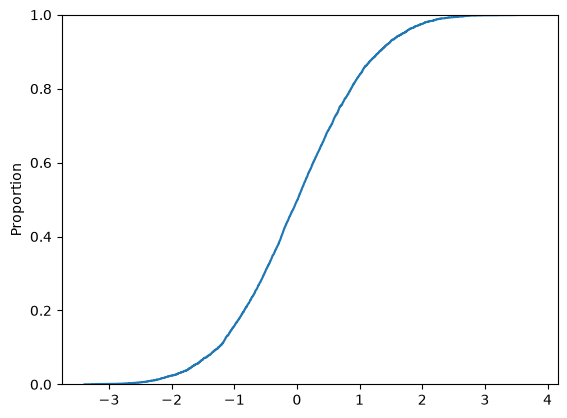

In [43]:
#1. Draw n = 32 values from Uniform[-sqrt(3), sqrt(3)]; these are your data. The choice of ensures each draw has mean 0 and variance 1.
rng = np.random.default_rng()
n = 32
reap =rng.uniform(-np.sqrt(3), np.sqrt(3), n)

#2. For this sample, compute the mean and multiply by np.sqrt(n).
reap_hat=np.mean(reap)*np.sqrt(n)
data2 = []
j = 5000

#3. Repeat the above process b = 5_000 times and plot the ECDF.
for L in range(j):
    reap =rng.uniform(-np.sqrt(3), np.sqrt(3), n)
    data2.append(np.mean(reap)*np.sqrt(n))

sns.ecdfplot(x = data2)

Q3.
In reliability engineering, we are often concerned with the proportions of failures that occur. For example,
the Challenger space shuttle exploded on January 28, 1986, when the primary and secondary o-rings failed.
Floods often occur because too many levees or pumps are compromised. In this simulation, we have 40 units
that each fail with probability , and we want to study the distribution of the survivors.
1. Flip n = 40 coins, which each come up heads with probability and tails with complementary
probability.
2. From the final count of heads, subtract the expected number of heads, n * p.
3. Divide by the standard deviation sqrt( n * p * (1-p) ).
4. Repeat the above process b = 5_000 times and plot the ECDF.
5. What distribution does this approach as increases?
    Like question 2, it appears to approach a normal distribution. It has the same S shape around x= 0. However, this graph is resembles a 'staircase' when we only simulate 40 coin flips
6. How do the results change as you adjust ?
    As I increase the amount of coin flips (n is the variable) the ECDF plot gets smother and resembles the graphs from Q1 and Q2

<Axes: ylabel='Proportion'>

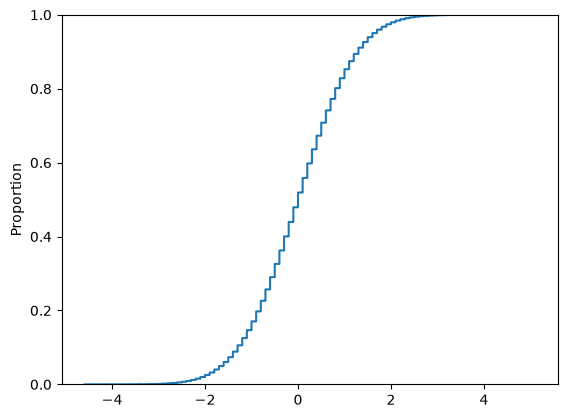

In [87]:
#1. Flip n = 40 coins, which each come up heads with probability and tails with complementary probability.
rng = np.random.default_rng()
n = 400
p = 0.5
reap = rng.choice([1, 0], size=n, p=[p, 1 - p])

#2. From the final count of heads, subtract the expected number of heads, n * p.
Q2 = reap.sum()-n*p
Q2

#3. Divide by the standard deviation sqrt( n * p * (1-p) ).
sd = np.sqrt(n*p*(1-p))
Q3 = Q2/sd

#4. Repeat the above process b = 5_000 times and plot the ECDF.
b = 500000
data3 = []
for reps in range(b):
    reap = rng.choice([1, 0], size=n, p=[p, 1 - p])
    Q2 = reap.sum()-n*p
    data3.append(Q2/sd)

sns.ecdfplot(x = data3)

Q5.
We're going to draw a sample of values, sort them, and track a particular rank. This is particularly useful for
understanding extreme events: We might be interested in the behavior of the biggest storm or earthquake
each year, but be working with a dataset about storms in general over 25 or 50 years.
1. Draw k = 20 values from Uniform[0, 1].
2. Sort them by size from smallest to largest.
3. Record the largest value.
4. Repeat n times and plot the ECDF.
5. Repeat the previous steps for each rank from 1 to K.
6. What distribution(s) does this process generate? How does the distribution depend on the rank?
This process generates the same distribution: Beta. However, the shape varies based on rank. The r-th smallest value follows a Beta(r, k + 1 - r) distribution. As the rank increases, the curve shifts from left to right across 0 to 1. The smaller the rank the more it clumps up at 0 and the larger it is the more it clumps up at 1.

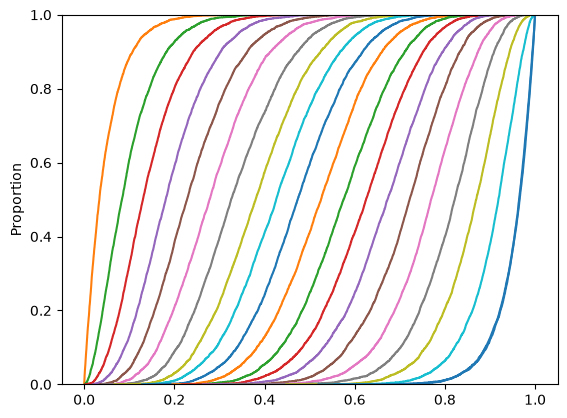

In [96]:
#1. Draw k = 20 values from Uniform[0, 1].
rng = np.random.default_rng()
k=20
draw = rng.uniform(0,1,k)

#2. Sort them by size from smallest to largest.
draw_sort = np.sort(draw)

#3. Record the largest value.
Largest = draw_sort[k-1]

#4. Repeat n times and plot the ECDF.
n = 5000
data5 = []

for reps in range(n):
    draw = rng.uniform(0,1,k)
    draw_sort = np.sort(draw)
    data5.append(draw_sort[k-1])

sns.ecdfplot(x = data5)

#5. Repeat the previous steps for each rank from 1 to K.
n = 5_000
for rank in range(k):
    data6 = []
    for reps in range(n):
        draw = rng.uniform(0, 1, k)
        draw_sort = np.sort(draw)
        data6.append(draw_sort[rank])
    sns.ecdfplot(x=data6)
